In [22]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from models import utils, parser_ops, UnrollNet
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
parser = parser_ops.get_parser()
args = parser.parse_args(args=[])

### Plot loss curves

### Load the data and generate images

In [23]:
# load the data, pad the mask and normalize k-space
# data = sio.loadmat(args.data_dir) 
data = sio.loadmat("data/data_new.mat") 
kspace_test,full_kspace, sens_maps, original_mask = data["kspace"], data["full_kspace"], data["sens_maps"], data["mask"]
# kspace_test,sens_maps, original_mask= data['kspace'], data['sens_maps'], data['mask']
nrow_GLOB, ncol_GLOB, ncoil_GLOB  = kspace_test.shape

# %%  zeropadded outer edges of k-space with no signal- check readme file for further explanations
# for coronal PD dataset, first 17 and last 16 columns of k-space has no signal
# in the training mask we set corresponding columns as 1 to ensure data consistency
test_mask = np.complex64(original_mask)
    
# Normalize the kspace to 0-1 region
kspace_test= kspace_test / np.max(np.abs(kspace_test[:]))

#generate network input and reference image
nw_input = utils.sense1(kspace_test * np.tile(test_mask[..., np.newaxis], (1, 1, ncoil_GLOB)),sens_maps)
ref_image = utils.sense1(full_kspace,sens_maps)

In [24]:
kspace_test.shape

(640, 368, 15)

/tmp/ipykernel_513601/2673570644.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(kspace_test[:, :, 3])), cmap="gray")


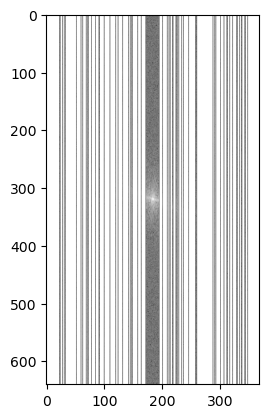

In [25]:
# show the kspace
plt.imshow(np.log(np.abs(kspace_test[:, :, 3])), cmap="gray")
plt.show()


### Load the model and perform the reconstruction

In [26]:
file_dir = os.path.join(os.getcwd(),'saved_models')
saved_model_dir = os.path.join(file_dir,args.saved_model_name)
model =UnrollNet.UnrolledNet(args,device=device).to(device)
model.load_state_dict(torch.load(os.path.join(saved_model_dir,'best.pth'))["model_state"])

model.eval()
with torch.no_grad():
    sens_maps  = torch.from_numpy(np.transpose(sens_maps[np.newaxis], (0, 3, 1, 2))).to(device)
    input_to_nw = torch.from_numpy(utils.complex2real(nw_input)[np.newaxis]).permute(0,3,1,2).to(device)
    trn_mask = torch.from_numpy(test_mask[np.newaxis]).to(device)
    nw_img_output, lamdas,nw_kspace_output = model(input_to_nw,trn_mask,trn_mask,sens_maps)

zs_ssl_recon = utils.real2complex(nw_img_output.permute(0,2,3,1).squeeze().to('cpu').numpy())

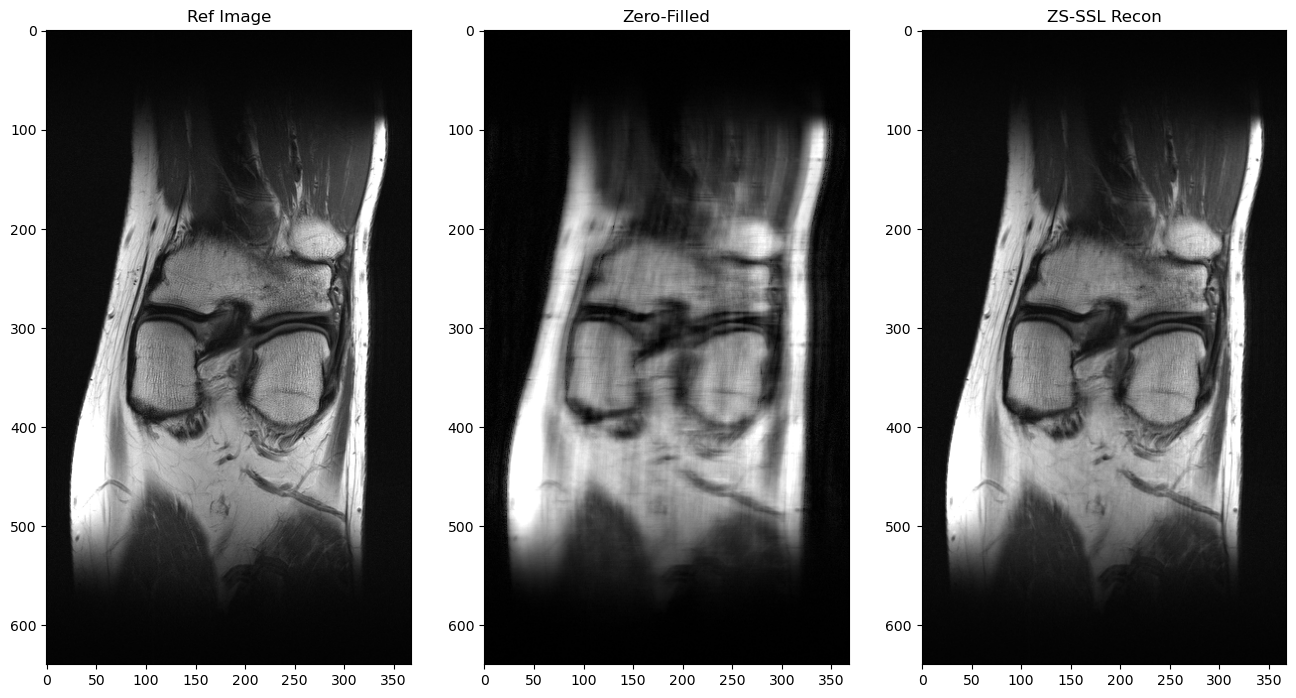

In [27]:
ref_image = np.abs(ref_image) / np.max(np.abs(ref_image[:]))
nw_input = np.abs(nw_input) / np.max(np.abs(nw_input[:]))
zs_ssl_recon = np.abs(zs_ssl_recon) / np.max(np.abs(zs_ssl_recon[:]))

vmax = float(0.6 * np.max(ref_image))
if not np.isfinite(vmax) or vmax <= 0:
    vmax = 1.0

plt.figure(figsize=(16, 16))
plt.subplot(1, 3, 1)
plt.imshow(ref_image, cmap="gray", vmin=0.0, vmax=vmax)
plt.title("Ref Image")
plt.subplot(1, 3, 2)
plt.imshow(nw_input, cmap="gray", vmin=0.0, vmax=vmax)
plt.title("Zero-Filled")
plt.subplot(1, 3, 3)
plt.imshow(zs_ssl_recon, cmap="gray", vmin=0.0, vmax=vmax)
plt.title("ZS-SSL Recon")
plt.show()